In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


With adaptation (van der Pol)

In [19]:
# Parameters
mu = 4.0        # nonlinearity / damping strength
sigma = 4.0     # noise intensity
dt = 0.01       # output / noise update step
T = 5000.0      # total time


In [20]:
# Pre-generate noise: piecewise-constant white noise approximation
# Each interval [k*dt, (k+1)*dt) gets an independent Gaussian kick
rng = np.random.default_rng(42)
N = int(T / dt)
noise_vals = rng.normal(0, 1, N) * sigma / np.sqrt(dt)

def vdp_noisy(t, state):
    xi, yi = state
    k = min(int(t / dt), N - 1)
    dxdt = yi
    dydt = mu * (1 - xi**2) * yi - xi + noise_vals[k]
    return [dxdt, dydt]



In [21]:

t_eval = np.linspace(0, T, N)
sol = solve_ivp(vdp_noisy, [0, T], [0.1, 0.0],
                t_eval=t_eval, method='RK45', max_step=dt)

x = sol.y[0]
y = sol.y[1]


In [22]:

# Define "states" as x > 0 (state +) vs x < 0 (state -)
# Compute residence durations in each state
sign = np.sign(x)
# Find zero-crossing indices
crossings = np.where(np.diff(sign) != 0)[0]
durations = np.diff(crossings) * dt

# Label each duration by which state it was in (sign of x just after crossing)
state_labels = sign[crossings[:-1] + 1]

dur_pos = durations[state_labels > 0]
dur_neg = durations[state_labels < 0]



Total crossings: 771
Mean residence (x>0): 6.430  (x<0): 6.550


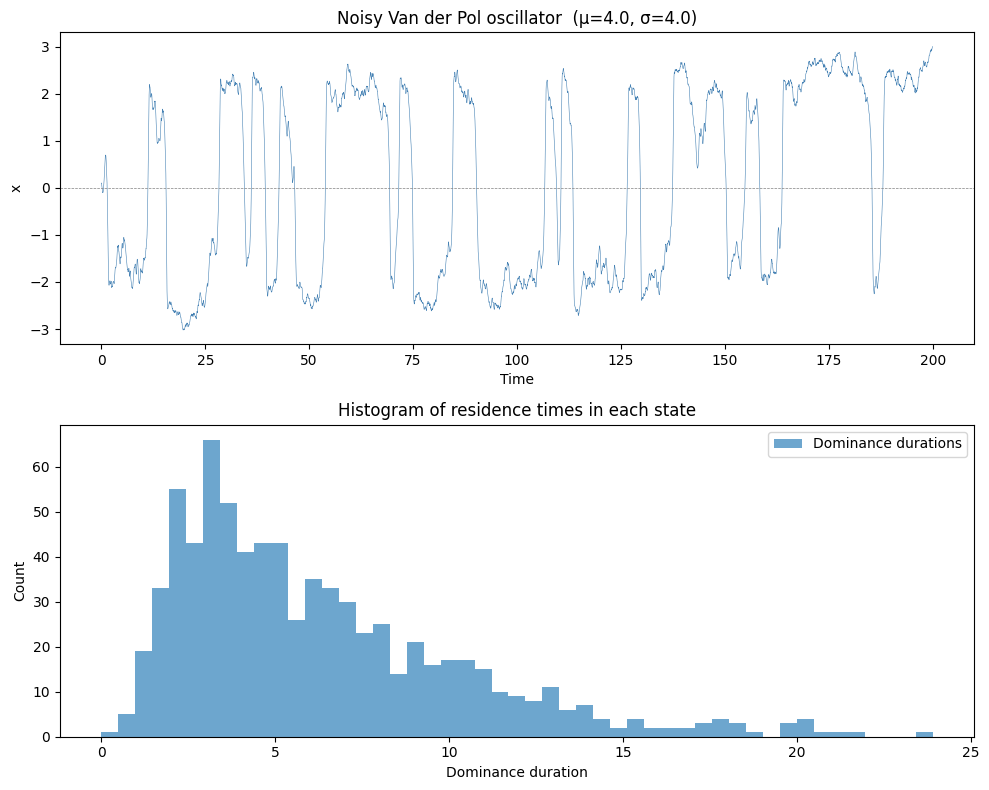

In [25]:
# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top: time series snippet
t_show = 200  # seconds to show
n_show = int(t_show / dt)
t_arr = np.arange(n_show) * dt
axes[0].plot(t_arr, x[:n_show], linewidth=0.4, color='steelblue')
axes[0].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('x')
axes[0].set_title(f'Noisy Van der Pol oscillator  (μ={mu}, σ={sigma})')

# Bottom: histogram of residence times
bins = np.linspace(0, np.percentile(durations, 99), 50)
#axes[1].hist(dur_pos, bins=bins, alpha=0.65, label='x > 0 (state +)', color='coral')
#axes[1].hist(dur_neg, bins=bins, alpha=0.65, label='x < 0 (state −)', color='steelblue')
axes[1].hist(durations, bins=bins, alpha=0.65, label='Dominance durations')
axes[1].set_xlabel('Dominance duration')
axes[1].set_ylabel('Count')
axes[1].set_title('Histogram of residence times in each state')
axes[1].legend()

plt.tight_layout()
plt.savefig('vdp_residence.png', dpi=150)
print(f"Total crossings: {len(crossings)}")
print(f"Mean residence (x>0): {dur_pos.mean():.3f}  (x<0): {dur_neg.mean():.3f}")

Noise based only

Total transitions: 2774
Mean residence (x>0): 3.606  (x<0): 3.589


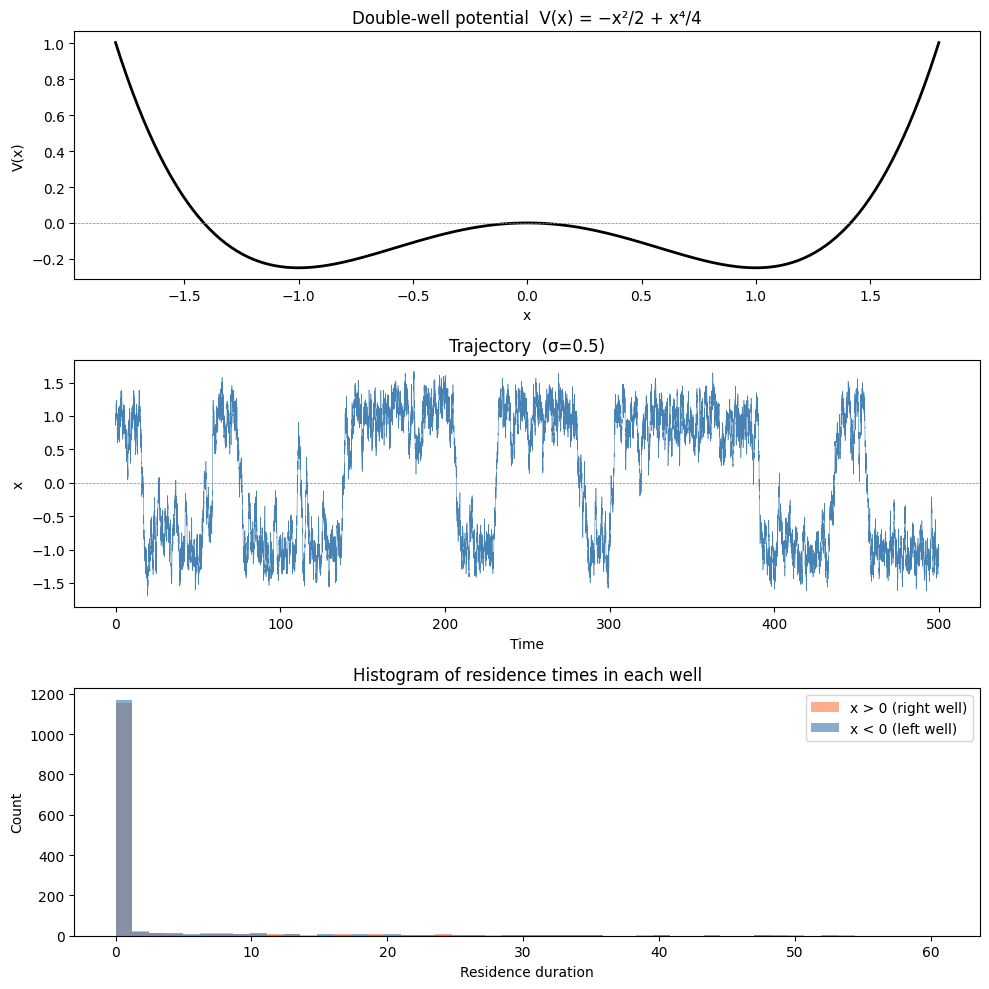

In [26]:
# Double-well (cusp) potential: V(x) = -x^2/2 + x^4/4
# Drift: f(x) = -dV/dx = x - x^3
# Stable fixed points at x = ±1, unstable at x = 0
# Transitions between wells driven entirely by additive noise

sigma = 0.5     # noise intensity
dt = 0.01       # noise update / max integration step
T = 10000.0     # total simulation time
N = int(T / dt)

In [ ]:

rng = np.random.default_rng(42)
noise_vals = rng.normal(0, 1, N) * sigma / np.sqrt(dt)

def double_well(t, state):
    x = state[0]
    k = min(int(t / dt), N - 1)
    dxdt = x - x**3 + noise_vals[k]
    return [dxdt]


In [ ]:

t_eval = np.linspace(0, T, N)
sol = solve_ivp(double_well, [0, T], [1.0],
                t_eval=t_eval, method='RK45', max_step=dt)

x = sol.y[0]


In [27]:

# --- Residence times ---
# State +1 when x > 0, state -1 when x < 0
sgn = np.sign(x)
crossings = np.where(np.diff(sgn) != 0)[0]
durations = np.diff(sol.t[crossings])
state_after = sgn[crossings[:-1] + 1]

dur_pos = durations[state_after > 0]
dur_neg = durations[state_after < 0]

print(f"Total transitions: {len(crossings)}")
print(f"Mean residence (x>0): {dur_pos.mean():.3f}  (x<0): {dur_neg.mean():.3f}")


Total transitions: 2774
Mean residence (x>0): 3.606  (x<0): 3.589


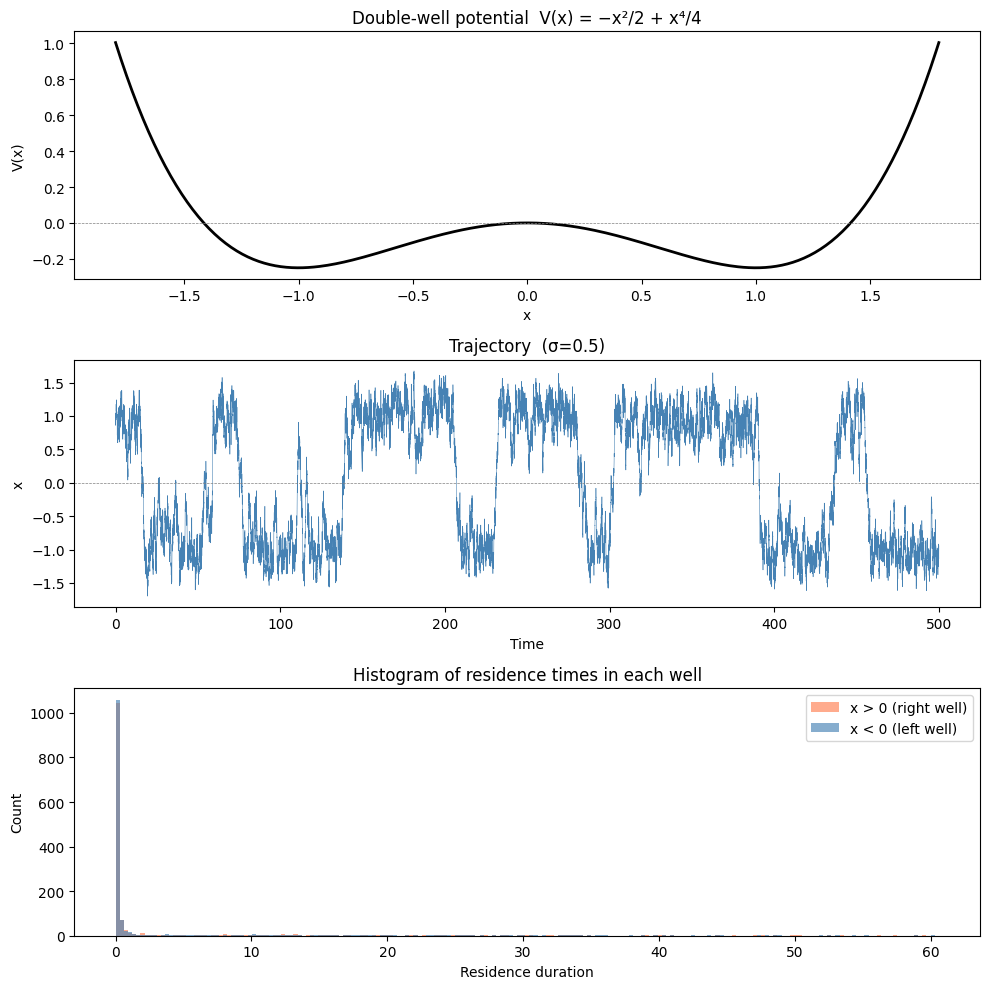

In [32]:

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Potential landscape
xp = np.linspace(-1.8, 1.8, 300)
V = -xp**2 / 2 + xp**4 / 4
axes[0].plot(xp, V, 'k', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('V(x)')
axes[0].set_title('Double-well potential  V(x) = −x²/2 + x⁴/4')
axes[0].axhline(0, color='grey', linewidth=0.5, linestyle='--')

# Time series snippet
t_show = 500
idx = sol.t <= t_show
axes[1].plot(sol.t[idx], x[idx], linewidth=0.4, color='steelblue')
axes[1].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('x')
axes[1].set_title(f'Trajectory  (σ={sigma})')

# Histogram of residence durations
bins = np.linspace(0, np.percentile(durations, 99), 200)
axes[2].hist(dur_pos, bins=bins, alpha=0.65, label='x > 0 (right well)', color='coral')
axes[2].hist(dur_neg, bins=bins, alpha=0.65, label='x < 0 (left well)', color='steelblue')
#axes[2].set_xlim(0, 10)
axes[2].set_xlabel('Residence duration')
axes[2].set_ylabel('Count')
axes[2].set_title('Histogram of residence times in each well')
axes[2].legend()

plt.tight_layout()
plt.savefig('double_well_residence.png', dpi=150)